In [1]:

# ============================
# CELL 1 — IMPORTS & SETTINGS
# ============================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz, find_peaks
import soundfile as sf
import os, math

plt.rcParams['figure.figsize'] = (12,4)


In [15]:

# ============================
# CELL 2 — PLOTTING UTILITIES
# ============================
def plot_wave(y, sr, title="Waveform", xlim=None):
    t = np.arange(len(y)) / sr
    plt.figure()
    plt.plot(t, y)
    if xlim:
        plt.xlim(xlim)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_spectrogram(y, sr, title="Spectrogram"):
    NFFT = 1024
    plt.figure()
    plt.specgram(y, NFFT=NFFT, Fs=sr, noverlap=NFFT//2)
    plt.title(title)
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.colorbar(label="Intensity")
    plt.show()

print("Plotting utilities ready.")

Plotting utilities ready.


In [16]:
# =========================================
# CELL 3 — OPTIONAL: RECORD AUDIO (Colab)
# =========================================
def record_audio(duration=4, fs=16000, filename='recorded.wav'):
    try:
        import sounddevice as sd
    except:
        raise RuntimeError("sounddevice not installed. Install or load WAV manually.")
    print(f"Recording {duration}s...")
    rec = sd.rec(int(duration*fs), samplerate=fs, channels=1, dtype='float32')
    sd.wait()
    rec = rec.flatten()
    sf.write(filename, rec, fs)
    print("Saved to", filename)
    return filename


In [17]:

# =====================================
# CELL 4 — LPC (Levinson-Durbin) FUNC
# =====================================
def levinson_durbin(r, order):
    a = np.zeros(order+1)
    e = r[0]
    if e == 0:
        return a, e
    a[0] = 1
    for i in range(1, order+1):
        acc = sum(a[j] * r[i-j] for j in range(1, i))
        k = -(r[i] + acc) / e
        a_new = a.copy()
        a_new[i] = k
        for j in range(1, i):
            a_new[j] = a[j] + k * a[i-j]
        e *= (1 - k*k)
        a = a_new
    return a, e


def lpc_autocorr(x, order):
    x = x - np.mean(x)
    r = np.correlate(x, x, mode='full')
    mid = len(r)//2
    r = r[mid: mid+order+1]
    a, e = levinson_durbin(r, order)
    return a, e

print("LPC core functions loaded.")

LPC core functions loaded.


In [18]:
# =============================================
# CELL 5 — TRY librosa.lpc, ELSE FALLBACK LPC
# =============================================
def compute_lpc(frame, order=14):
    try:
        import librosa
        a = librosa.lpc(frame, order)
        residual = lfilter(a, 1.0, frame)
        return a, residual
    except:
        a, _ = lpc_autocorr(frame, order)
        residual = lfilter(a, 1.0, frame)
        return a, residual

print("LPC compute wrapper ready.")

# ==========================================
# CELL 6 — LPC RECONSTRUCTION FUNCTION
# ==========================================
def reconstruct_from_lpc(a, residual):
    return lfilter([1.0], a, residual)

LPC compute wrapper ready.


In [19]:
# ==========================================
# CELL 7 — FORMANT ESTIMATION FUNCTION
# ==========================================
def lpc_to_formants(a, fs, n_formants=3, bw_limit=400):
    roots = np.roots(a)
    roots = [r for r in roots if np.imag(r) > 0]
    ang = np.angle(roots)
    freqs = ang * (fs / (2*np.pi))
    bw = -1/np.pi * np.log(np.abs(roots)) * fs

    formants = []
    for f, b in zip(freqs, bw):
        if f > 90 and f < fs/2 and b < bw_limit:
            formants.append((f, b))

    return sorted(formants, key=lambda x: x[0])[:n_formants]


def plot_vocal_tract_response(a, fs, title="Vocal Tract Frequency Response (1/A)"):
    w, h = freqz([1.0], a, worN=4096, fs=fs)
    mag = 20*np.log10(np.abs(h)+1e-12)
    plt.figure()
    plt.plot(w, mag)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(title)
    peaks, _ = find_peaks(mag, height=np.max(mag)-30)
    plt.plot(w[peaks], mag[peaks], 'x')
    plt.grid(True)
    plt.show()
    return w, mag, peaks


print("Formant estimation ready.")

Formant estimation ready.


IPA vowel table loaded.
Loaded speech:  example_speech.wav


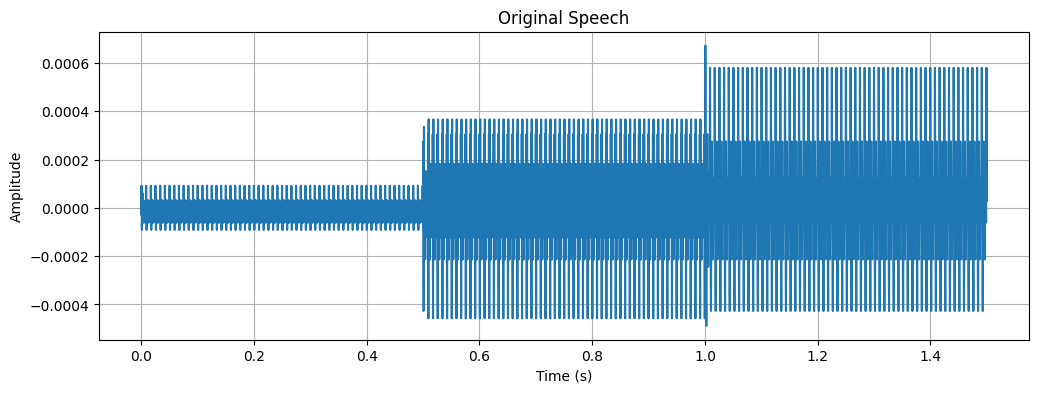

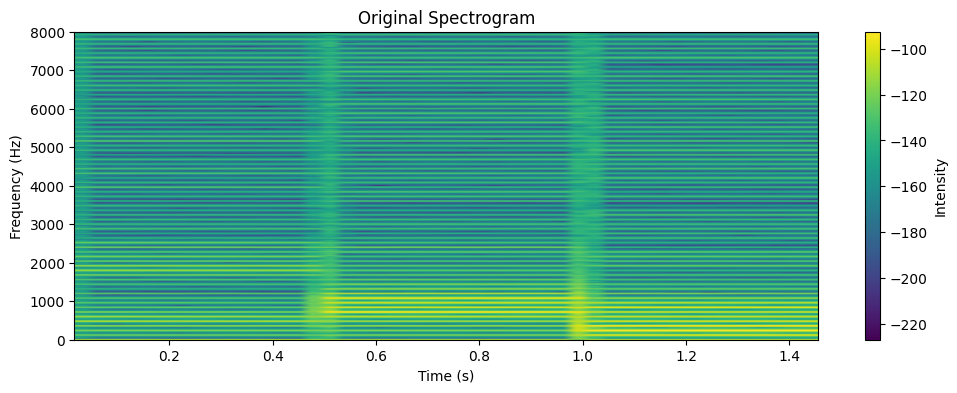

In [20]:
# ================================
# CELL 8 — IPA VOWEL TABLE
# ================================
ipa_table = {
    '/i/': (270, 2290),
    '/e/': (530, 1840),
    '/a/': (730, 1090),
    '/o/': (570, 840),
    '/u/': (300, 870)
}
print("IPA vowel table loaded.")

# ======================================
# CELL 9 — LOAD / SYNTHESIZE SPEECH
# ======================================
filename = "example_speech.wav"
if not os.path.exists(filename):
    print("No file found — synthesizing vowel demo...")
    fs = 16000
    def synth_vowel(formants, f0=120, dur=0.4):
        t = np.linspace(0, dur, int(dur*fs), endpoint=False)
        src = np.zeros_like(t)
        src[::int(fs/f0)] = 1
        y = src.copy()
        for fc, bw in formants:
            r = math.exp(-math.pi*bw/fs)
            th = 2*math.pi*fc/fs
            a = [1, -2*r*math.cos(th), r*r]
            b = [1-r, 0, 0]
            y = lfilter(b, a, y)
        return y

    x = np.concatenate([
        synth_vowel([(530,70),(1840,90),(2480,120)], dur=0.5),
        synth_vowel([(730,80),(1090,90),(2440,120)], dur=0.5),
        synth_vowel([(300,60),(870,90),(2240,120)], dur=0.5)
    ])
    sf.write(filename, x, fs)

x, fs = sf.read(filename)
if x.ndim > 1:
    x = x[:,0]

print("Loaded speech: ", filename)
plot_wave(x, fs, "Original Speech")
plot_spectrogram(x, fs, "Original Spectrogram")


Frame extracted.


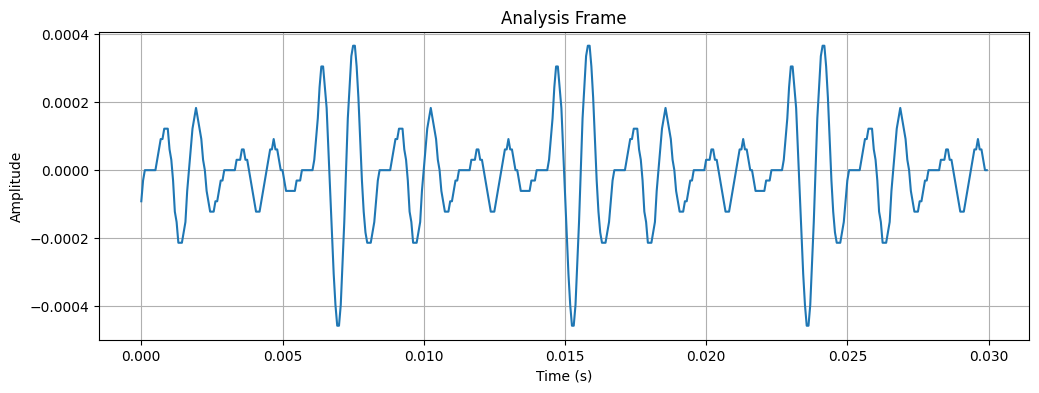

/var/folders/vm/ddfwc92d3bs2wrcpb_l9qw1m0000gp/T/ipykernel_6467/2620173495.py:20: UserWarning: Only one segment is calculated since parameter NFFT (=1024) >= signal length (=480).
  plt.specgram(y, NFFT=NFFT, Fs=sr, noverlap=NFFT//2)


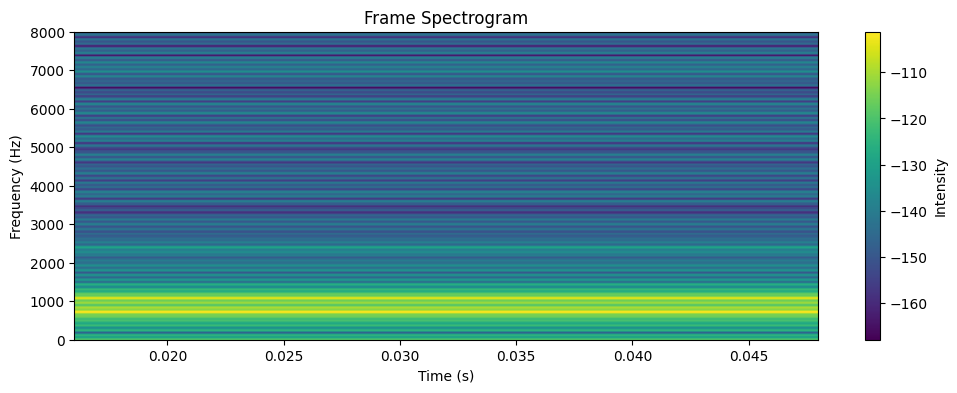

LPC Coefficients: [ 1.         -1.08346373 -0.18825926  0.19928622  0.3538085   0.04006352
  0.00397898 -0.10890538  0.09491666  0.00661306  0.210489   -0.27579588
 -0.01791825  0.0084462   0.19683807]


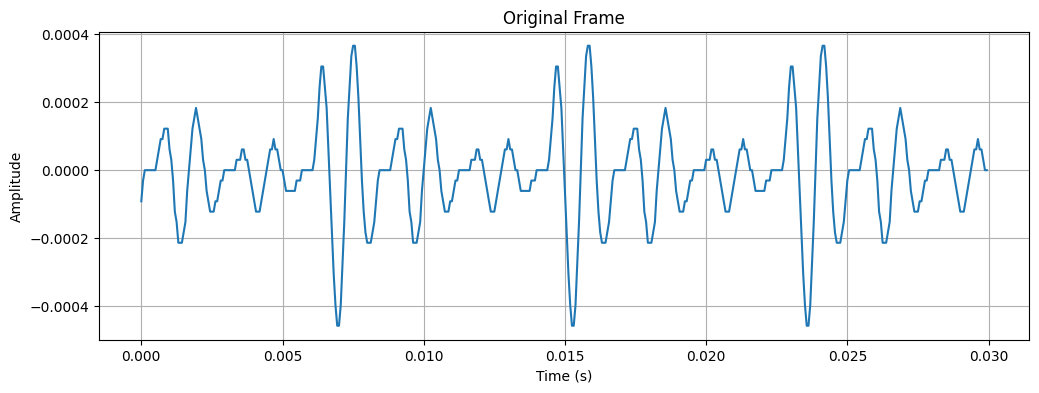

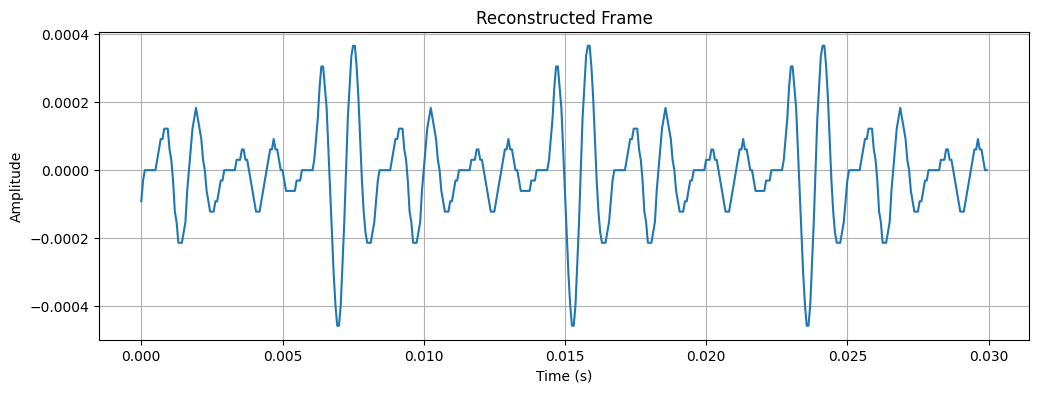

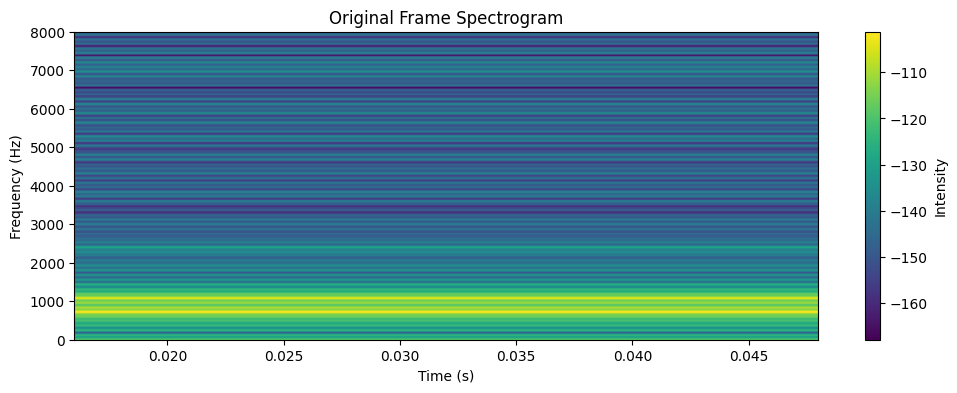

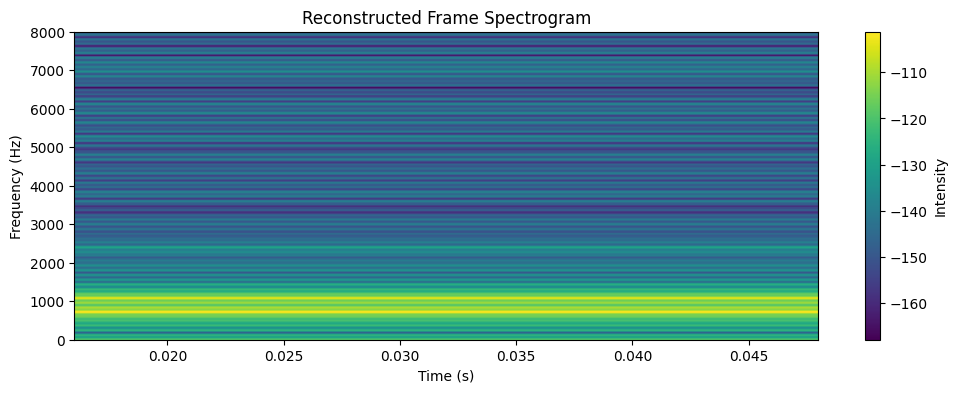

Reconstruction SNR: 39.62 dB


In [21]:
# ======================================
# CELL 10 — FRAME SELECTION
# ======================================
frame_duration = 0.03
N = int(frame_duration * fs)
middle = len(x)//2
frame = x[middle-N//2 : middle+N//2]
print("Frame extracted.")
plot_wave(frame, fs, "Analysis Frame")
plot_spectrogram(frame, fs, "Frame Spectrogram")


# ======================================
# CELL 11 — LPC ANALYSIS
# ======================================
order = 14
a, residual = compute_lpc(frame, order)
print("LPC Coefficients:", a)


# ======================================
# CELL 12 — RECONSTRUCTION
# ======================================
recon = reconstruct_from_lpc(a, residual)


plot_wave(frame, fs, "Original Frame")
plot_wave(recon, fs, "Reconstructed Frame")
plot_spectrogram(frame, fs, "Original Frame Spectrogram")
plot_spectrogram(recon, fs, "Reconstructed Frame Spectrogram")


snr = 10*np.log10(np.sum(frame**2) / (np.sum((frame-recon)**2)+1e-9))
print(f"Reconstruction SNR: {snr:.2f} dB")

Estimated formants (Hz, bandwidth Hz):
  F1: 716.0 Hz, BW: 60.6 Hz
  F2: 1080.0 Hz, BW: 81.3 Hz
  F3: 2425.3 Hz, BW: 548.4 Hz
  F4: 7228.5 Hz, BW: 519.4 Hz


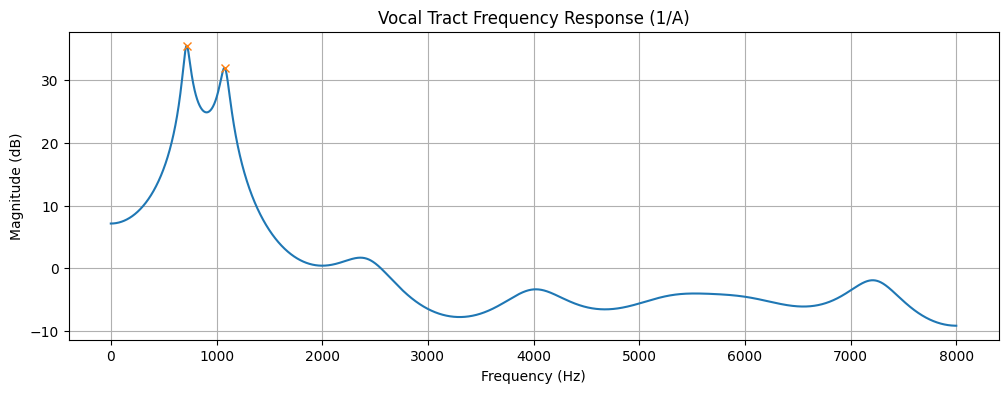


Peaks marked on the response (Hz): [ 718.8 1076.2]


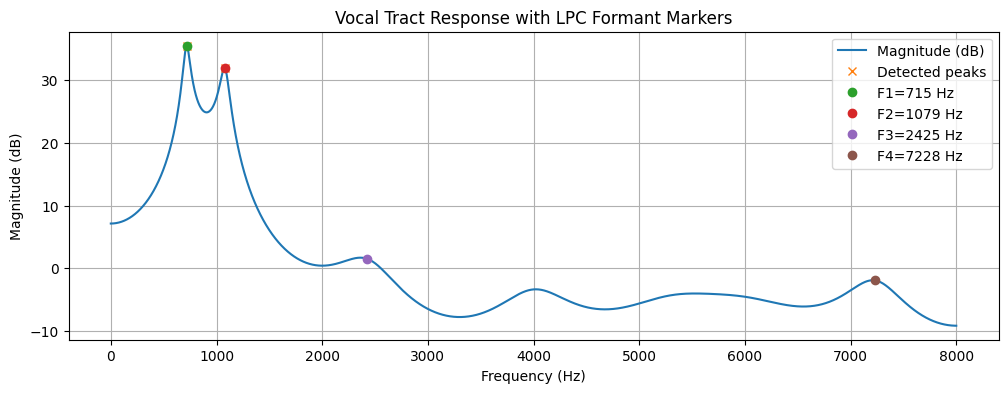


--- Comparison to IPA typical F1/F2 values (abs. diff in Hz) ---
Estimated (F1, F2) = (715, 1079)

Vowel  | F1_typ   F2_typ |    diff_F1    diff_F2
------------------------------------------------
/i/    |    270     2290 |        445       1211
/e/    |    530     1840 |        185        761
/a/    |    730     1090 |         15         11
/o/    |    570      840 |        145        239
/u/    |    300      870 |        415        209


In [13]:
# =========================
# CELL 13 — FORMANT ESTIMATION
# =========================

# Estimate formants from the LPC coefficients (up to 5 for safety)
formants = lpc_to_formants(a, fs, n_formants=5, bw_limit=600)

# Nicely print the estimated formants (frequency and bandwidth)
if len(formants) == 0:
    print("No formants detected. Check LPC order / frame selection.")
else:
    print("Estimated formants (Hz, bandwidth Hz):")
    for i, (f, b) in enumerate(formants, start=1):
        print(f"  F{i}: {f:.1f} Hz, BW: {b:.1f} Hz")

# Plot vocal tract frequency response and mark peaks
w, mag, peaks = plot_vocal_tract_response(a, fs, title="Vocal Tract Frequency Response (1/A)")

# Show detected peak frequencies (if any)
peak_freqs = w[peaks] if (peaks is not None and len(peaks) > 0) else np.array([])
if peak_freqs.size:
    print("\nPeaks marked on the response (Hz):", np.round(peak_freqs, 1))

# Mark the LPC-derived formant frequencies on the frequency response plot
# (re-plot with markers so they are clearly visible)
plt.figure()
plt.plot(w, mag, label="Magnitude (dB)")
# mark peaks
if peak_freqs.size:
    plt.plot(peak_freqs, mag[peaks], 'x', label='Detected peaks')
# mark LPC formants
for i, (f, bw) in enumerate(formants, start=1):
    # find nearest index for plotting
    idx = np.argmin(np.abs(w - f))
    plt.plot(w[idx], mag[idx], 'o', label=f"F{i}={int(f)} Hz")
plt.title("Vocal Tract Response with LPC Formant Markers")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Compare estimated F1/F2 to IPA typical table (if F1/F2 available)
# -------------------------
est_f1 = int(formants[0][0]) if len(formants) > 0 else None
est_f2 = int(formants[1][0]) if len(formants) > 1 else None

print("\n--- Comparison to IPA typical F1/F2 values (abs. diff in Hz) ---")
if est_f1 is None or est_f2 is None:
    print("Insufficient formant estimates (need at least two).")
else:
    print(f"Estimated (F1, F2) = ({est_f1}, {est_f2})\n")
    # Print table of differences
    print("{:6s} | {:>6s} {:>8s} | {:>10s} {:>10s}".format("Vowel", "F1_typ", "F2_typ", "diff_F1", "diff_F2"))
    print("-"*48)
    for v, (f1_typ, f2_typ) in ipa_table.items():
        d1 = abs(est_f1 - f1_typ)
        d2 = abs(est_f2 - f2_typ)
        print(f"{v:6s} | {f1_typ:6d} {f2_typ:8d} | {d1:10d} {d2:10d}")

# Optionally save the comparison to a CSV (uncomment to enable)
# import csv
# csv_path = "lpc_outputs/formant_comparison.csv"
# os.makedirs(os.path.dirname(csv_path), exist_ok=True)
# with open(csv_path, "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(["vowel", "F1_typ", "F2_typ", "est_F1", "est_F2", "diff_F1", "diff_F2"])
#     for v, (f1_typ, f2_typ) in ipa_table.items():
#         d1 = abs(est_f1 - f1_typ) if est_f1 is not None else None
#         d2 = abs(est_f2 - f2_typ) if est_f2 is not None else None
#         writer.writerow([v, f1_typ, f2_typ, est_f1, est_f2, d1, d2])
# print("Saved comparison CSV to", csv_path)
